In [2]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [18]:
df = pd.read_parquet('TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS10"] = df["HS10"].astype('int64')
    
df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

In [19]:
df.head( )

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,I_COMMODITY_SDESC,time,COMM_LVL,imports,duty
0,TOTAL FOR ALL COUNTRIES,773010,0,602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,773010.0,0.0
1,TOTAL FOR ALL COUNTRIES,6177543,0,602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,6177543.0,0.0
2,TOTAL FOR ALL COUNTRIES,135786,0,602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,135786.0,0.0
3,TOTAL FOR ALL COUNTRIES,169439,0,602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,169439.0,0.0
4,TOTAL FOR ALL COUNTRIES,2177498,25345,602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,2177498.0,25345.0


In [20]:
matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['Relevance'] = matlist['Relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['Relevance'] = pd.Categorical(
    matlist['Relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist.rename(columns={'HS10_Code': 'HS10'}, inplace=True)

In [21]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'Relevance']], on='HS10', how='left')

In [22]:
# Combine Low and Medium into a single category
df['Relevance'] = df['Relevance'].cat.add_categories(['Low/Medium'])

df.loc[df['Relevance'].isin(['Low', 'Medium']), 'Relevance'] = 'Low/Medium'

df['Relevance'] = df['Relevance'].cat.remove_unused_categories()

In [23]:
df["tariff_rate"] = df["duty"] / df["imports"]


In [24]:
# Create tariff category based on 2025-10 rates
oct_2025 = df[df['time'] == '2025-10'].copy()

# Calculate weighted mean tariff for 2025-10
threshold = oct_2025['duty'].sum() / oct_2025['imports'].sum()
print(f"Weighted mean tariff threshold: {threshold:.4f} ({threshold*100:.2f}%)")

# Calculate each HS10's tariff rate in 2025-10
hs10_tariffs = oct_2025.groupby('HS10').agg({'duty': 'sum', 'imports': 'sum'})
hs10_tariffs['tariff_rate_2025_10'] = hs10_tariffs['duty'] / hs10_tariffs['imports']

# Create mapping dictionary
tariff_category_map = {}
for hs10, row in hs10_tariffs.iterrows():
    if row['tariff_rate_2025_10'] >= threshold:
        tariff_category_map[hs10] = 'High Tariff'
    else:
        tariff_category_map[hs10] = 'Low Tariff'

# Add tariff category to df
df['Tariff_Category'] = df['HS10'].map(tariff_category_map)
df['Tariff_Category'] = df['Tariff_Category'].astype('category')

print(f"\nTariff category distribution:")
print(df['Tariff_Category'].value_counts())

Weighted mean tariff threshold: 0.1091 (10.91%)

Tariff category distribution:
High Tariff    1675036
Low Tariff      770631
Name: Tariff_Category, dtype: int64


In [25]:
grp = df.groupby(['Relevance', 'time'])

grp_sum = grp[['imports']].sum().reset_index()

grp_duty = grp[['duty']].sum().reset_index()

grp_merged = pd.merge(grp_sum, grp_duty, on=['Relevance', 'time'])

In [26]:
grp_merged.head()

,Relevance,time,imports,duty
0,High,2013-01-01,1.085750e+10,18791155.0
1,High,2013-02-01,9.923037e+09,17579269.0
2,High,2013-03-01,1.051108e+10,19101394.0
3,High,2013-04-01,1.040376e+10,21632853.0
4,High,2013-05-01,1.097322e+10,22552255.0


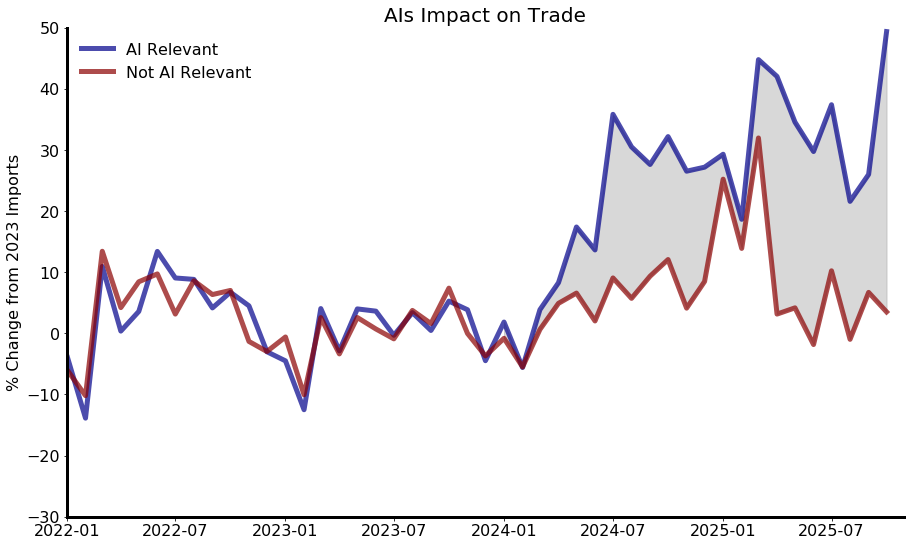

In [27]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['Relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["imports"] / foo["imports"].loc["2023"].sum() - 1.0) , 
        color = "darkblue", alpha = 0.7, linewidth = 5, label='AI Relevant')

foo2 = grp_sum[grp_sum['Relevance']=='Low/Medium'].copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["imports"] / foo2["imports"].loc["2023"].sum() - 1.0) ,
         color = "darkred", alpha = 0.7, linewidth = 5, label='Not AI Relevant')

# Shade between lines after 2024-01
cutoff_date = dt.datetime(2024, 1, 1)
mask = foo.index >= cutoff_date
ax.fill_between(
    foo.index[mask], 
    100*(12*foo["imports"][mask] / foo["imports"].loc["2023"].sum() - 1.0),
    100*(12*foo2["imports"][mask] / foo2["imports"].loc["2023"].sum() - 1.0),
    alpha=0.3, 
    color='gray'
)


ax.set_title("AIs Impact on Trade", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2025,10,30)])

ax.set_ylim(-30,50)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("% Change from 2023 Imports", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")
# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

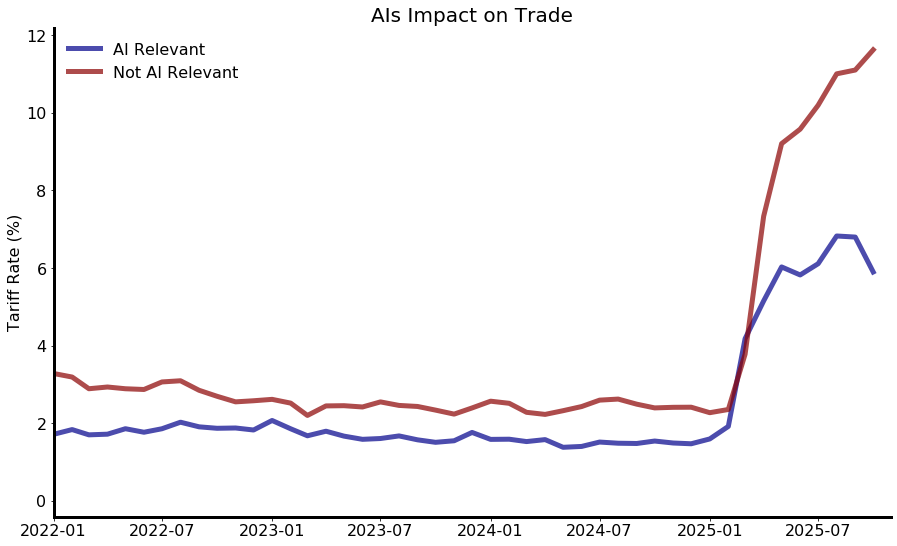

In [28]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_merged[grp_merged['Relevance']=='High'].copy()
foo["tariff_rate"] = foo["duty"] / foo["imports"]

foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(foo["tariff_rate"]) , 
        color = "darkblue", alpha = 0.7, linewidth = 5, label='AI Relevant')

foo2 = grp_merged[grp_merged['Relevance']=='Low/Medium'].copy()
foo2["tariff_rate"] = foo2["duty"] / foo2["imports"]            
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(foo2["tariff_rate"]) ,
         color = "darkred", alpha = 0.7, linewidth = 5, label='Not AI Relevant')

# # Shade between lines after 2024-01
# cutoff_date = dt.datetime(2024, 1, 1)
# mask = foo.index >= cutoff_date
# ax.fill_between(
#     foo.index[mask], 
#     100*(12*foo["imports"][mask] / foo["imports"].loc["2023"].sum() - 1.0),
#     100*(12*foo2["imports"][mask] / foo2["imports"].loc["2023"].sum() - 1.0),
#     alpha=0.3, 
#     color='gray'
# )


ax.set_title("AIs Impact on Trade", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2025,10,30)])

# ax.set_ylim(-30,50)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Tariff Rate (%)", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")
# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [31]:
df.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,I_COMMODITY_SDESC,time,COMM_LVL,imports,duty,Relevance,tariff_rate,Tariff_Category
0,TOTAL FOR ALL COUNTRIES,773010,0,602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,773010.0,0.0,Low/Medium,0.00000,Low Tariff
1,TOTAL FOR ALL COUNTRIES,6177543,0,602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,6177543.0,0.0,Low/Medium,0.00000,High Tariff
2,TOTAL FOR ALL COUNTRIES,135786,0,602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,135786.0,0.0,Low/Medium,0.00000,Low Tariff
3,TOTAL FOR ALL COUNTRIES,169439,0,602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,169439.0,0.0,Low/Medium,0.00000,Low Tariff
4,TOTAL FOR ALL COUNTRIES,2177498,25345,602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,2177498.0,25345.0,Low/Medium,0.01164,High Tariff


In [38]:
# Drop all High category from Relevance column
dfnoai = df[df['Relevance'] != 'High'].copy()

grp = dfnoai.groupby(['Tariff_Category', 'time'])

grp_sum = grp[['imports']].sum().reset_index()

grp_duty = grp[['duty']].sum().reset_index()

grp_merged = pd.merge(grp_sum, grp_duty, on=['Tariff_Category', 'time'])

grp_merged["tariff"] = grp_merged["duty"] / grp_merged["imports"]

In [46]:
grp_merged.head()

,Tariff_Category,time,imports,duty,tariff
0,High Tariff,2013-01-01,5.370552e+10,1.671135e+09,0.031117
1,High Tariff,2013-02-01,5.092629e+10,1.546993e+09,0.030377
2,High Tariff,2013-03-01,5.027986e+10,1.320436e+09,0.026262
3,High Tariff,2013-04-01,5.418296e+10,1.471651e+09,0.027161
4,High Tariff,2013-05-01,5.516792e+10,1.508994e+09,0.027353


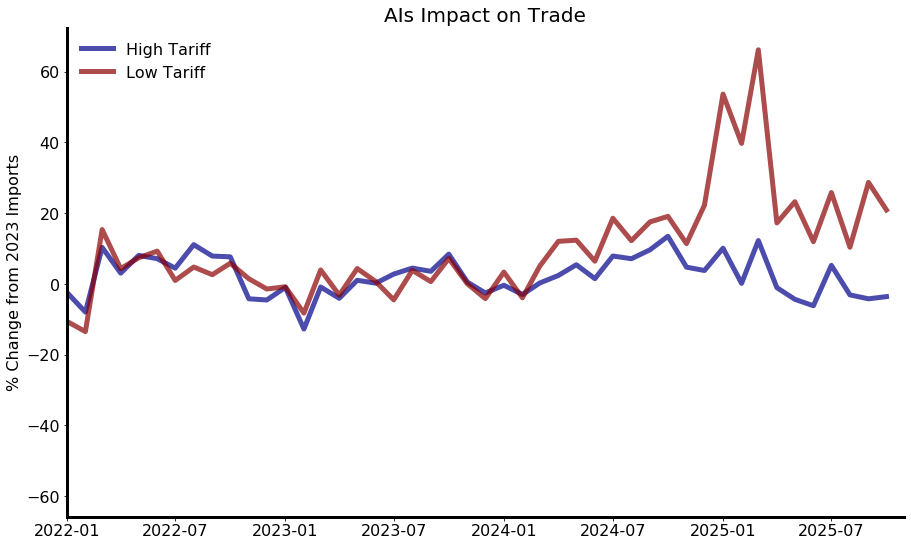

In [42]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['Tariff_Category']=='High Tariff'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["imports"] / foo["imports"].loc["2023"].sum() - 1.0) , 
        color = "darkblue", alpha = 0.7, linewidth = 5, label='High Tariff')

foo2 = grp_sum[grp_sum['Tariff_Category']=='Low Tariff'].copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["imports"] / foo2["imports"].loc["2023"].sum() - 1.0) ,
         color = "darkred", alpha = 0.7, linewidth = 5, label='Low Tariff')

# # Shade between lines after 2024-01
# cutoff_date = dt.datetime(2025, 4, 1)
# mask = foo.index >= cutoff_date
# ax.fill_between(
#     foo.index[mask], 
#     100*(12*foo["imports"][mask] / foo["imports"].loc["2023"].sum() - 1.0),
#     100*(12*foo2["imports"][mask] / foo2["imports"].loc["2023"].sum() - 1.0),
#     alpha=0.3, 
#     color='gray'
# )


ax.set_title("AIs Impact on Trade", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2025,10,30)])

#ax.set_ylim(-30,70)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("% Change from 2023 Imports", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")
# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

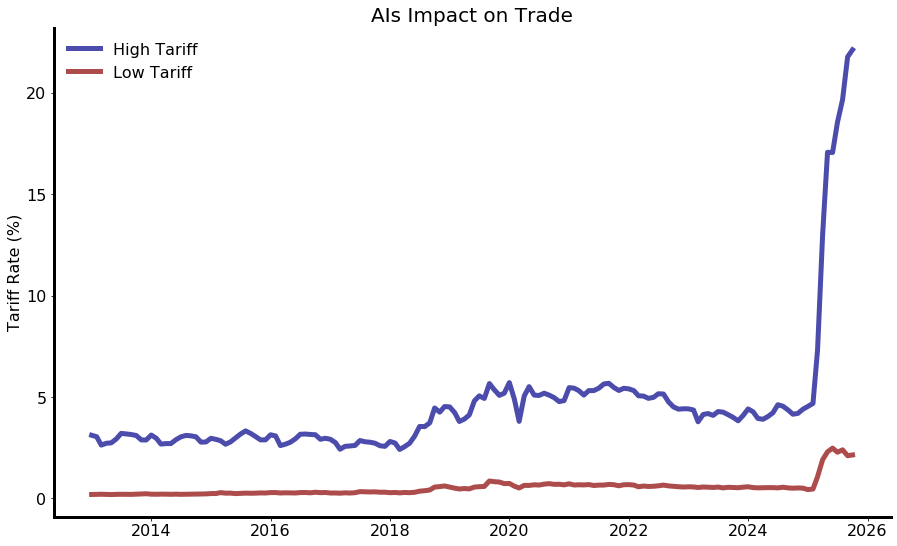

In [50]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_merged[grp_merged['Tariff_Category']=='High Tariff'].copy()

foo.set_index('time', inplace=True)

ax.plot(foo.index, 100*(foo["tariff"]) , 
        color = "darkblue", alpha = 0.7, linewidth = 5, label='High Tariff')

foo2 = grp_merged[grp_merged['Tariff_Category']=='Low Tariff'].copy()
                  
      
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(foo2["tariff"]) ,
         color = "darkred", alpha = 0.7, linewidth = 5, label='Low Tariff')

# # Shade between lines after 2024-01
# cutoff_date = dt.datetime(2024, 1, 1)
# mask = foo.index >= cutoff_date
# ax.fill_between(
#     foo.index[mask], 
#     100*(12*foo["imports"][mask] / foo["imports"].loc["2023"].sum() - 1.0),
#     100*(12*foo2["imports"][mask] / foo2["imports"].loc["2023"].sum() - 1.0),
#     alpha=0.3, 
#     color='gray'
# )


ax.set_title("AIs Impact on Trade", fontsize = 20)

#ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2025,10,30)])

# ax.set_ylim(-30,50)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Tariff Rate (%)", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")
# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()